# 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
from time import time
from glob import glob
from collections import defaultdict as default_dict

# Matplotlib
from matplotlib import pyplot as plt

# Tensorflow
#os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
from tensorflow.keras import Model, Input
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess_input

# Sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, davies_bouldin_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Seaborn
import seaborn as sns


# 2. Préparation des données

In [2]:
path = "/content/drive/MyDrive/data/Flipkart"
#path = "./data/Flipkart"

In [3]:
data = pd.read_csv(path+'/cleaned_data.csv')

In [4]:
data.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,...,category,tokenized_description,stemmed_description,combined_postag_wnet,lemmatized_description,lemmatized_description_text,tokenized_product_name,combined_postag_wnet_product_name,lemmatized_product_name,lemmatized_product_name_text
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,...,Home Furnishing,"['key', 'features', 'elegance', 'polyester', '...","['key', 'featur', 'eleg', 'polyest', 'multicol...","[('key', 'n'), ('features', 'v'), ('elegance',...","['key', 'feature', 'elegance', 'polyester', 'm...",key feature elegance polyester multicolor abst...,"['elegance', 'polyester', 'multicolor', 'abstr...","[('elegance', 'n'), ('polyester', 'n'), ('mult...","['elegance', 'polyester', 'multicolor', 'abstr...",elegance polyester multicolor abstract eyelet ...
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,...,Baby Care,"['specifications', 'sathiyas', 'cotton', 'bath...","['specif', 'sathiya', 'cotton', 'bath', 'towel...","[('specifications', 'n'), ('sathiyas', 'n'), (...","['specification', 'sathiyas', 'cotton', 'bath'...",specification sathiyas cotton bath towel bath ...,"['sathiyas', 'cotton', 'bath', 'towel']","[('sathiyas', 'n'), ('cotton', 'n'), ('bath', ...","['sathiyas', 'cotton', 'bath', 'towel']",sathiyas cotton bath towel
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,...,Baby Care,"['key', 'features', 'eurospa', 'cotton', 'terr...","['key', 'featur', 'eurospa', 'cotton', 'terri'...","[('key', 'n'), ('features', 'v'), ('eurospa', ...","['key', 'feature', 'eurospa', 'cotton', 'terry...",key feature eurospa cotton terry face towel se...,"['eurospa', 'cotton', 'terry', 'face', 'towel'...","[('eurospa', 'n'), ('cotton', 'n'), ('terry', ...","['eurospa', 'cotton', 'terry', 'face', 'towel'...",eurospa cotton terry face towel set
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,...,Home Furnishing,"['key', 'features', 'santosh', 'royal', 'fashi...","['key', 'featur', 'santosh', 'royal', 'fashion...","[('key', 'n'), ('features', 'v'), ('santosh', ...","['key', 'feature', 'santosh', 'royal', 'fashio...",key feature santosh royal fashion cotton print...,"['santosh', 'royal', 'fashion', 'cotton', 'pri...","[('santosh', 'n'), ('royal', 'a'), ('fashion',...","['santosh', 'royal', 'fashion', 'cotton', 'pri...",santosh royal fashion cotton print king sized ...
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,...,Home Furnishing,"['key', 'features', 'jaipur', 'print', 'cotton...","['key', 'featur', 'jaipur', 'print', 'cotton',...","[('key', 'n'), ('features', 'v'), ('jaipur', '...","['key', 'feature', 'jaipur', 'print', 'cotton'...",key feature jaipur print cotton floral king si...,"['jaipur', 'print', 'cotton', 'floral', 'king'...","[('jaipur', 'n'), ('print', 'n'), ('

In [5]:
data[['product_category_tree', 'category', 'uniq_id']].head(10)

,product_category_tree,category,uniq_id
0,"[""Home Furnishing >> Curtains & Accessories >>...",Home Furnishing,55b85ea15a1536d46b7190ad6fff8ce7
1,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",Baby Care,7b72c92c2f6c40268628ec5f14c6d590
2,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",Baby Care,64d5d4a258243731dc7bbb1eef49ad74
3,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",Home Furnishing,d4684dcdc759dd9cdf41504698d737d8
4,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",Home Furnishing,6325b6870c54cd47be6ebfbffa620ec7
5,"[""Watches >> Wrist Watches >> Maserati Time Wr...",Watches,893aa5ed55f7cff2eccea7758d7a86bd
6,"[""Watches >> Wrist Watches >> Camerii Wrist Wa...",Watches,f355cc1ccb08bd0d283ed979b7ee7515
7,"[""Watches >> Wrist Watches >> T STAR Wrist Wat...",Watches,dd0e3470a7e6ed76fd69c2da27721041
8,"[""Watches >> Wrist Watches >> Alfajr Wrist Wat...",Watches,41384da51732c0b4df3de8f395714fbb
9,"[""Watches >> Wrist Watches >> TAG Heuer Wrist ...",Watches,710ed5f2393a4b9e8823aa0029f71f93


In [6]:
data[['product_category_tree', 'category', 'uniq_id']].tail(10)

,product_category_tree,category,uniq_id
1040,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,3b465b02720ef7c930cb2e065a8fc05d
1041,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,b1644f47c7dfa58f8c06677f2a27ee09
1042,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,057836ecde71565f8ebdd576e41fdc96
1043,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,38782cce965307ddcdbedfcb7fa409c3
1044,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,be0f39341d771aac57084970f1ed6425
1045,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,958f54f4c46b53c8a0a9b8167d9140bc
1046,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,fd6cbcc22efb6b761bd564c28928483c
1047,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,5912e037d12774bb73a2048f35a00009
1048,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,c3edc504d1b4f0ba6224fa53a43a7ad6
1049,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,f2f027ad6a6df617c9f125173da71e44


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   uniq_id                            1050 non-null   object 
 1   crawl_timestamp                    1050 non-null   object 
 2   product_url                        1050 non-null   object 
 3   product_name                       1050 non-null   object 
 4   product_category_tree              1050 non-null   object 
 5   pid                                1050 non-null   object 
 6   retail_price                       1049 non-null   float64
 7   discounted_price                   1049 non-null   float64
 8   image                              1050 non-null   object 
 9   is_FK_Advantage_product            1050 non-null   bool   
 10  description                        1050 non-null   object 
 11  product_rating                     1050 non-null   objec

In [8]:
data.describe()

,retail_price,discounted_price
count,1049.000000,1049.000000
mean,2186.197331,1584.527169
std,7639.229411,7475.099680
min,35.000000,35.000000
25%,555.000000,340.000000
50%,999.000000,600.000000
75%,1999.000000,1199.000000
max,201000.000000,201000.000000


In [9]:
# Fonction pour convertir un DataFrame en tf.data.Dataset

preprocessor_map = {
    'resnet50': resnet_preprocess_input,
    'vgg16': vgg_preprocess_input
}

def load_img(path, label):
    # Charger l'image depuis le chemin
    img = tf.io.read_file(path)
    # Décoder l'image en tenseur
    img = tf.image.decode_jpeg(img, channels=3)
    # Redimensionner l'image
    img = tf.image.resize(img, [224, 224])

    return img, label

def preprocess(img, model='resnet50'):

    # Appliquer le prétraitement
    img = preprocessor_map[model](img)

    return img


def df_to_dataset(dataframe, batch_size=32, shuffle=True, encoded_category=False):
    paths = dataframe["imagepath"].values
    labels = dataframe["category"].values
    if encoded_category:
        labels = dataframe["encoded_category"].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [10]:
le = LabelEncoder()
data["imagepath"] = data["image"].apply(lambda x: os.path.join(path, 'Images', x))
data['encoded_category'] = le.fit_transform(data['category'])

# Split train/val/test
train_df, temp_df = train_test_split(data, test_size=0.3, stratify=data["category"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.2, stratify=temp_df["category"], random_state=42)

# Transformation du dataframe en tf.data.datset
data_ds = df_to_dataset(data)

In [11]:
'''
images = glob(path+"/Images"+"*/*.jpg")
ids = [os.path.splitext(os.path.basename(fname))[0] for fname in images]

labels = []
for idx in ids:
    label = data.loc[data.uniq_id == idx, 'category'].values[0]
    labels.append(label)


data_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path+"/Images",
    labels=labels,
    image_size=(224,224),
    seed=123,
    batch_size=32,
    shuffle=True,
    verbose=True
)

label_encoder = LabelEncoder()
true_labels = label_encoder.fit_transform(labels)
true_classes = labels
'''

'\nimages = glob(path+"/Images"+"*/*.jpg")\nids = [os.path.splitext(os.path.basename(fname))[0] for fname in images]\n\nlabels = []\nfor idx in ids:\n    label = data.loc[data.uniq_id == idx, \'category\'].values[0]\n    labels.append(label)\n\n\ndata_ds = tf.keras.preprocessing.image_dataset_from_directory(\n    path+"/Images",\n    labels=labels,\n    image_size=(224,224),\n    seed=123,\n    batch_size=32,\n    shuffle=True,\n    verbose=True\n)\n\nlabel_encoder = LabelEncoder()\ntrue_labels = label_encoder.fit_transform(labels)\ntrue_classes = labels\n'

CPU times: user 8.57 s, sys: 1.77 s, total: 10.3 s
Wall time: 4.97 s


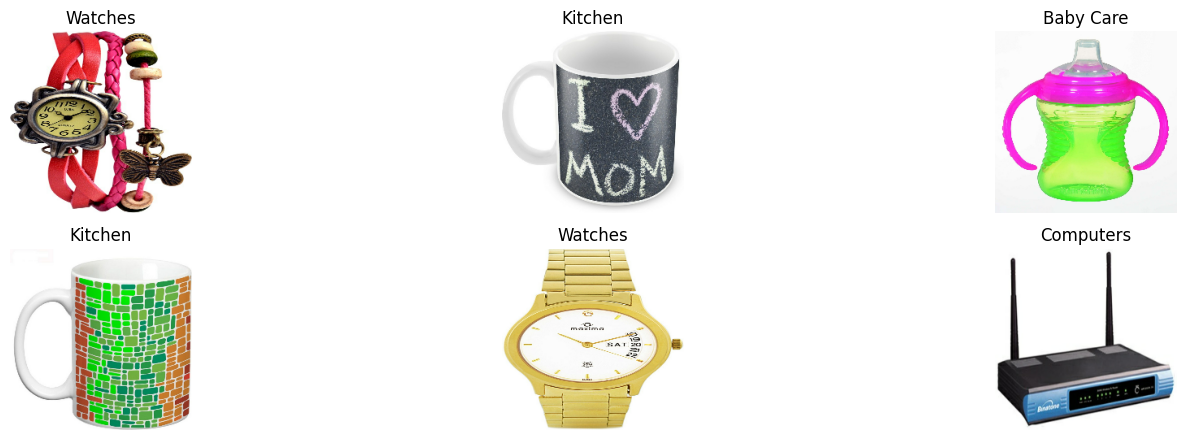

In [12]:
%%time
plt.figure(figsize=(18, 8))
for images, l in data_ds.take(4):
  for i in range(6):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(l[i].numpy().decode('utf-8'))
    plt.axis("off")

# 3. Extraction de caractéristiques via CNN (Transfer Learning)

In [13]:
def extract_features(dataset, model):
    features_list = []
    labels_list = []

    for images, labels in dataset:
        features = model.predict(images)
        features_list.append(features)
        labels_list.append(labels.numpy())

    # Concaténer tous les batches
    features_array = np.concatenate(features_list, axis=0)
    labels_array = np.concatenate(labels_list, axis=0)

    return features_array, labels_array

In [14]:
results = default_dict(dict)

## 3.1. Extraction des features avec ResNet50

In [15]:
resnet50_data_ds = data_ds.map(lambda x,y: (resnet_preprocess_input(x), y))

In [16]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
base_model.trainable = False
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [17]:
%%time
resnet50_features = base_model.predict(resnet50_data_ds)

33/33 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step
CPU times: user 4min 30s, sys: 22.8 s, total: 4min 53s
Wall time: 48.1 s


In [18]:
print("Data features shape:", resnet50_features.shape)

Data features shape: (1050, 2048)


### 3.1.1. Réduction de dimensions

#### | PCA

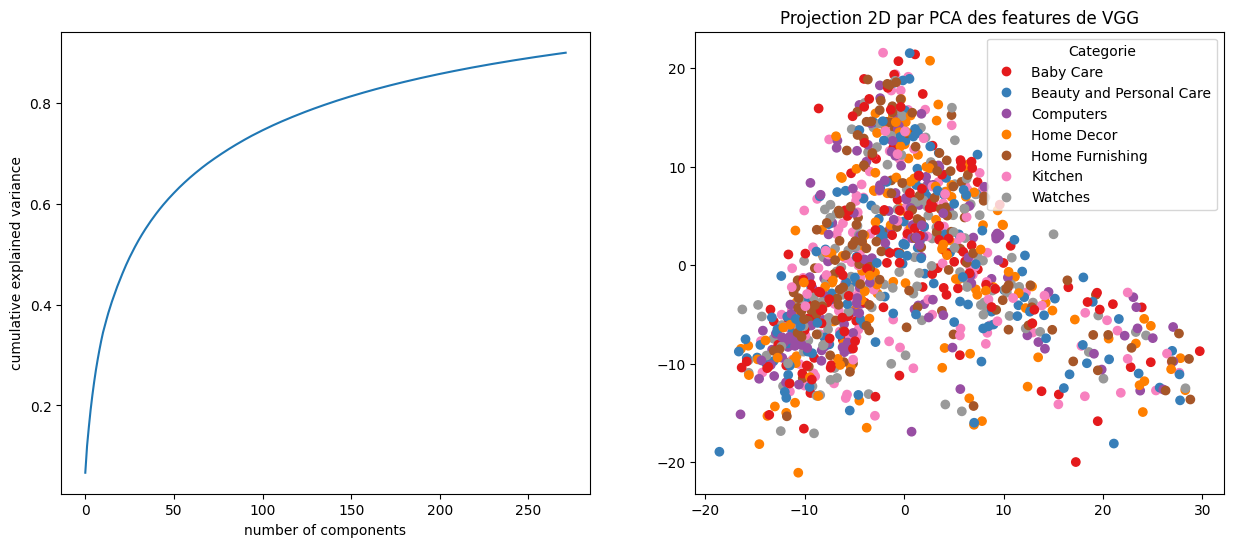

CPU times: user 5.18 s, sys: 34.3 ms, total: 5.21 s
Wall time: 885 ms


In [19]:
%%time
scaler = StandardScaler()
pca = PCA(n_components=0.9)

scaled_resnet50_features = scaler.fit_transform(resnet50_features)
resnet50_X_pca = pca.fit_transform(resnet50_features)

fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(121)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

ax = fig.add_subplot(122)
scatter = plt.scatter(resnet50_X_pca[:,0],resnet50_X_pca[:,1], c=data.encoded_category.tolist(), cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(data.category).tolist(), loc="best", title="Categorie")
plt.title("Projection 2D par PCA des features de VGG")

plt.show()

In [20]:
resnet50_X_pca

array([[  4.971265  ,  -7.0090714 , -15.17948   , ...,   0.38761717,
          0.33179393,   0.36346397],
       [ -9.0999775 ,  -4.7624803 ,   5.757366  , ...,   1.1951263 ,
         -1.5148735 ,   1.108208  ],
       [-13.088394  ,  -5.702989  ,   8.604727  , ...,   0.13766985,
          1.0419005 ,  -0.08720297],
       ...,
       [ -1.4356214 ,   1.2527412 ,  -2.3633327 , ...,   0.58005   ,
         -0.9137007 ,   0.6882322 ],
       [ -0.3409187 ,  16.07226   ,  -0.3252027 , ...,   0.09383792,
         -0.18777715,  -0.85157216],
       [  8.800885  ,  -4.2342067 ,   9.337264  , ...,   0.25015783,
         -0.28474414,   0.21572584]], dtype=float32)

#### | TSNE

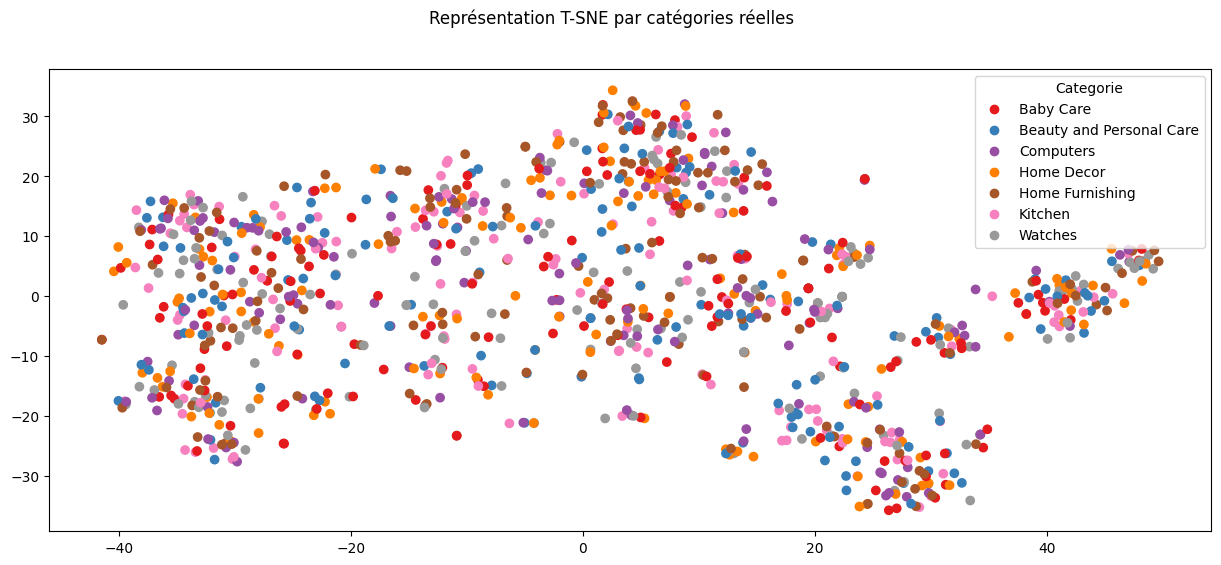

CPU times: user 12.3 s, sys: 18.7 ms, total: 12.3 s
Wall time: 3.02 s


In [22]:
%%time
fig = plt.figure(figsize=(15,6))
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
resnet50_X_tsne = tsne.fit_transform(resnet50_X_pca)
scatter = plt.scatter(resnet50_X_tsne[:,0],resnet50_X_tsne[:,1], c=data.encoded_category, cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(data.category).tolist(), loc="best", title="Categorie")

plt.suptitle("Représentation T-SNE par catégories réelles")
plt.show()

### 3.1.2. Kmeans clustering

In [23]:
def tsne_visu_fct(X_tsne, y_cat_num, labels, ARI):
    fig = plt.figure(figsize=(15,6))
    ax = fig.add_subplot(121)

    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=y_cat_num, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(y_cat_num), loc="best", title="Categorie")
    plt.title(f"Représentation des produits par catégories réelles")

    ax = fig.add_subplot(122)
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=labels, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(labels), loc="best", title="Clusters")
    plt.title(f"Représentation des produits par clusters => ARI={ARI}")
    plt.show()

ARI :  -0.0011


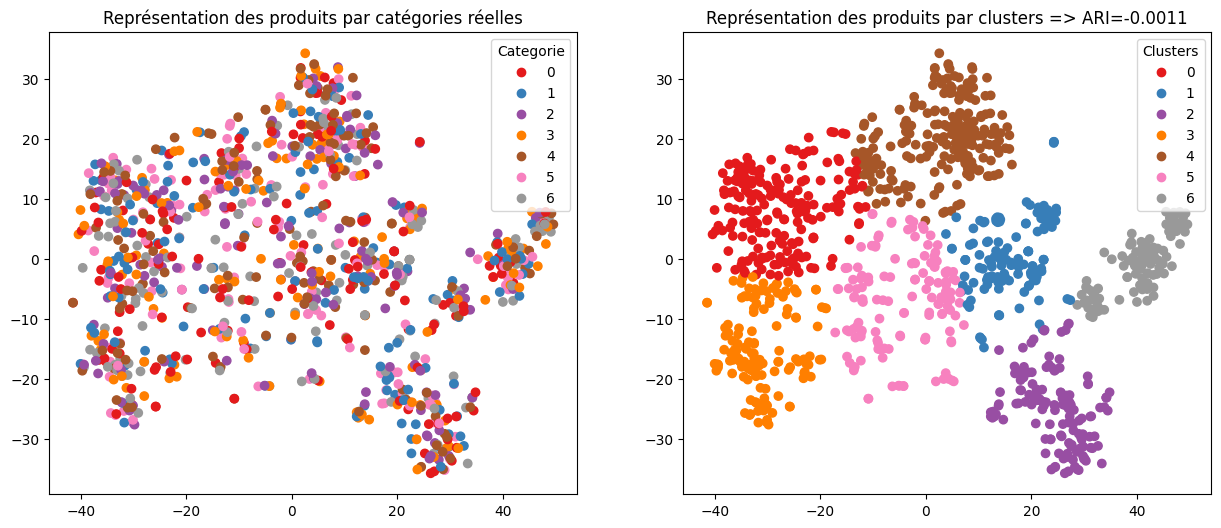

CPU times: user 2.29 s, sys: 61.1 ms, total: 2.35 s
Wall time: 655 ms


In [24]:
%%time

# Détermination des clusters à partir des données reduites
k=7

cls = KMeans(n_clusters=k, n_init=100, random_state=42)
clusters = cls.fit_predict(resnet50_X_tsne)
ARI = np.round(adjusted_rand_score(data.encoded_category, clusters),4)
results["Resnet50"] = {
    'Silhouette score': silhouette_score(resnet50_X_tsne, clusters, metric='euclidean'),
    'Davies-Bouldin score': davies_bouldin_score(resnet50_X_tsne, clusters),
}
print("ARI : ", ARI)
tsne_visu_fct(resnet50_X_tsne, data.encoded_category, clusters, ARI)

In [25]:
results

defaultdict(dict,
            {'Resnet50': {'Silhouette score': np.float32(0.46836385),
              'Davies-Bouldin score': np.float64(0.6897476423941413)}})

In [26]:
clustered_df = pd.DataFrame(data.category, columns=['category'])
clustered_df['cluster'] = clusters

In [27]:
clustered_df

,category,cluster
0,Home Furnishing,6
1,Baby Care,0
2,Baby Care,0
3,Home Furnishing,4
4,Home Furnishing,3
...,...,...
1045,Baby Care,5
1046,Baby Care,3
1047,Baby Care,5
1048,Baby Care,4


In [28]:
clustered_df.groupby("cluster")["category"].value_counts().to_frame().reset_index()

,cluster,category,count
0,0,Computers,38
1,0,Kitchen,28
2,0,Baby Care,27
3,0,Beauty and Personal Care,27
4,0,Home Decor,26
5,0,Watches,25
6,0,Home Furnishing,24
7,1,Watches,21
8,1,Computers,19
9,1,Baby Care,18


In [29]:
from sklearn import metrics
conf_mat = metrics.confusion_matrix(data.encoded_category, clustered_df.cluster)
print(conf_mat)

[[27 18 17 23 28 22 15]
 [27 18 27 17 30 14 17]
 [38 19 18 15 29 20 11]
 [26 16 21 19 33 17 18]
 [24 18 15 18 40 22 13]
 [28 17 22 17 30 23 13]
 [25 21 17 24 22 22 19]]


In [30]:
print(metrics.classification_report(data.encoded_category, clustered_df.cluster))

              precision    recall  f1-score   support

           0       0.14      0.18      0.16       150
           1       0.14      0.12      0.13       150
           2       0.13      0.12      0.13       150
           3       0.14      0.13      0.13       150
           4       0.19      0.27      0.22       150
           5       0.16      0.15      0.16       150
           6       0.18      0.13      0.15       150

    accuracy                           0.16      1050
   macro avg       0.16      0.16      0.15      1050
weighted avg       0.16      0.16      0.15      1050



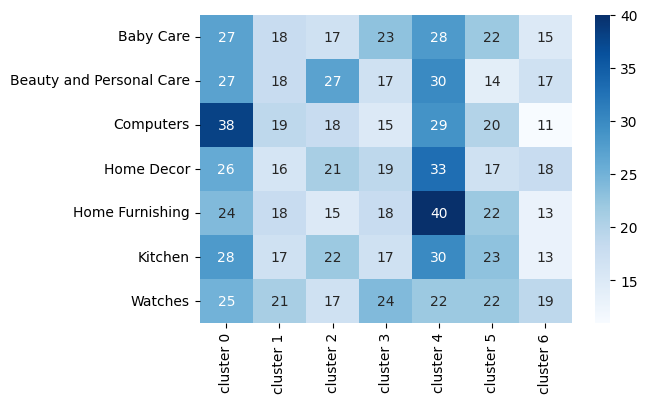

In [31]:
df_cm = pd.DataFrame(conf_mat, index = np.unique(data.category),
                  columns = [f"cluster {i}" for i in np.unique(data.encoded_category)])
plt.figure(figsize = (6,4))
sns.heatmap(df_cm, annot=True, cmap="Blues")
plt.show()

## 3.2 EXtraction des features avec VGG16

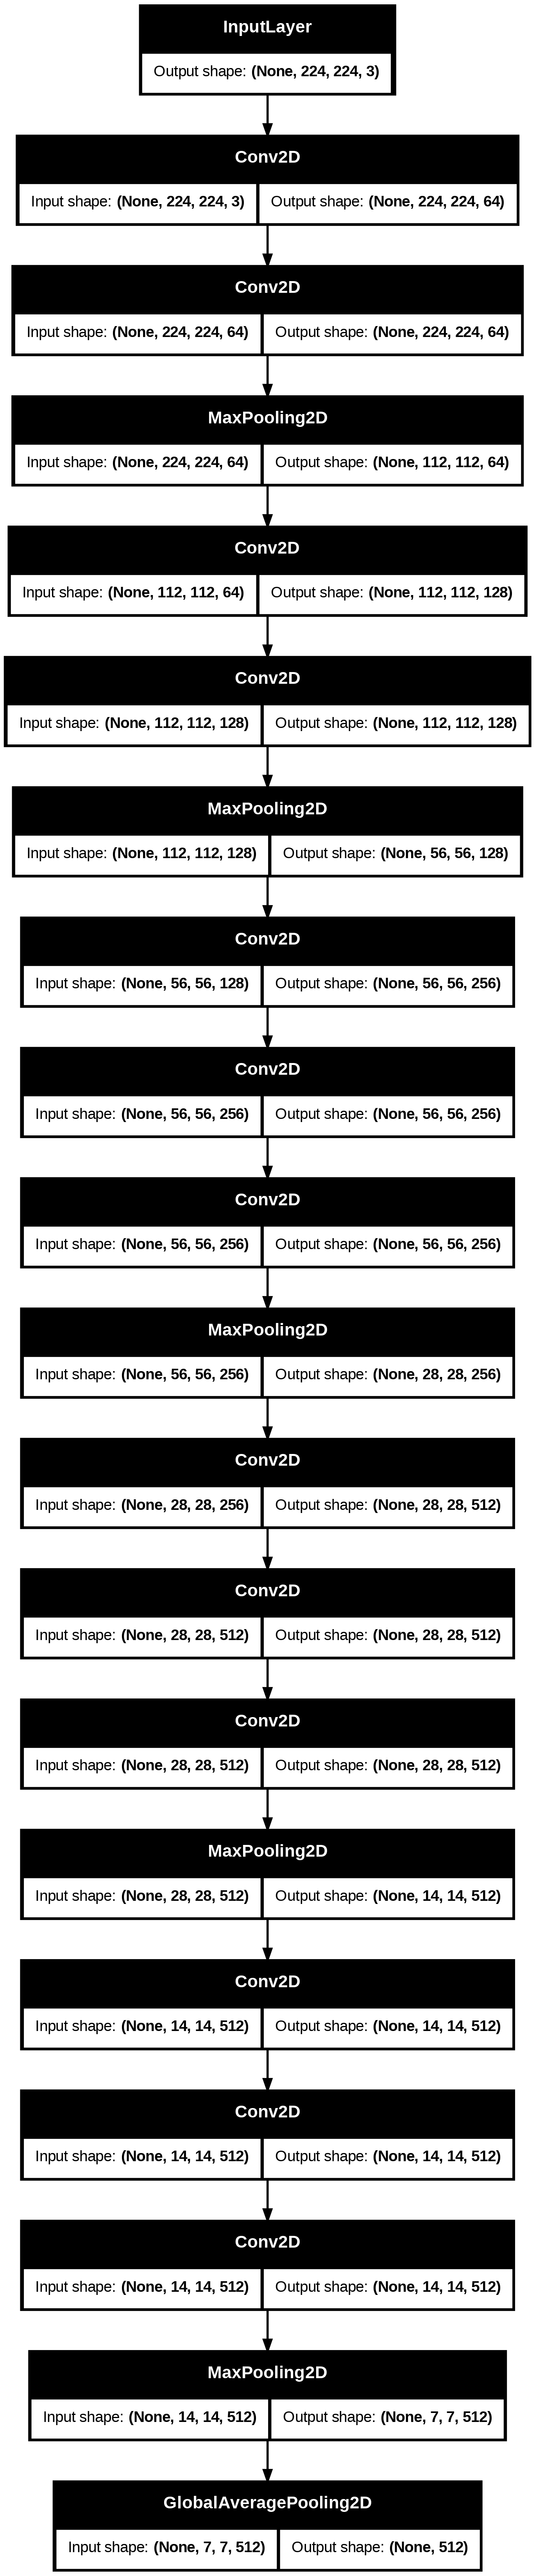

In [32]:
vgg_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
tf.keras.utils.plot_model(vgg_model, show_shapes=True)

In [33]:
%%time
vgg_data_ds = data_ds.map(lambda x,y: (vgg_preprocess_input(x), y))
vgg_features = vgg_model.predict(vgg_data_ds)

Cause: could not parse the source code of <function <lambda> at 0x7b0de0b07ba0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7b0de0b07ba0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
33/33 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step
CPU times: user 13min 18s, sys: 37.5 s, total: 13min 56s
Wall time: 1min 55s


In [34]:
vgg_features.shape

(1050, 512)

### 3.2.1. Réduction de dimensions

#### | PCA

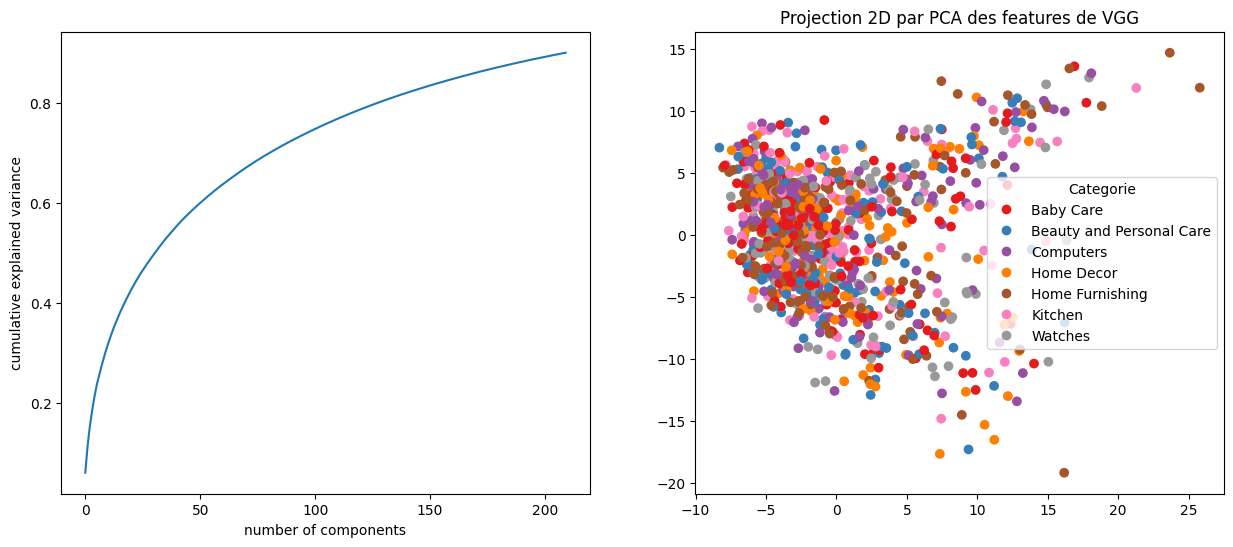

CPU times: user 1.77 s, sys: 14.1 ms, total: 1.79 s
Wall time: 400 ms


In [35]:
%%time
scaler = StandardScaler()
scaled_vgg_features = scaler.fit_transform(vgg_features)
pca = PCA(n_components=0.9)
vgg_x_pca = pca.fit_transform(scaled_vgg_features)

fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(121)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
ax = fig.add_subplot(122)

scatter = plt.scatter(vgg_x_pca[:,0],vgg_x_pca[:,1], c=data.encoded_category.tolist(), cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(data.category).tolist(), loc="best", title="Categorie")
plt.title("Projection 2D par PCA des features de VGG")
plt.show()

In [36]:
pca.components_.shape

(210, 512)

#### | T-SNE

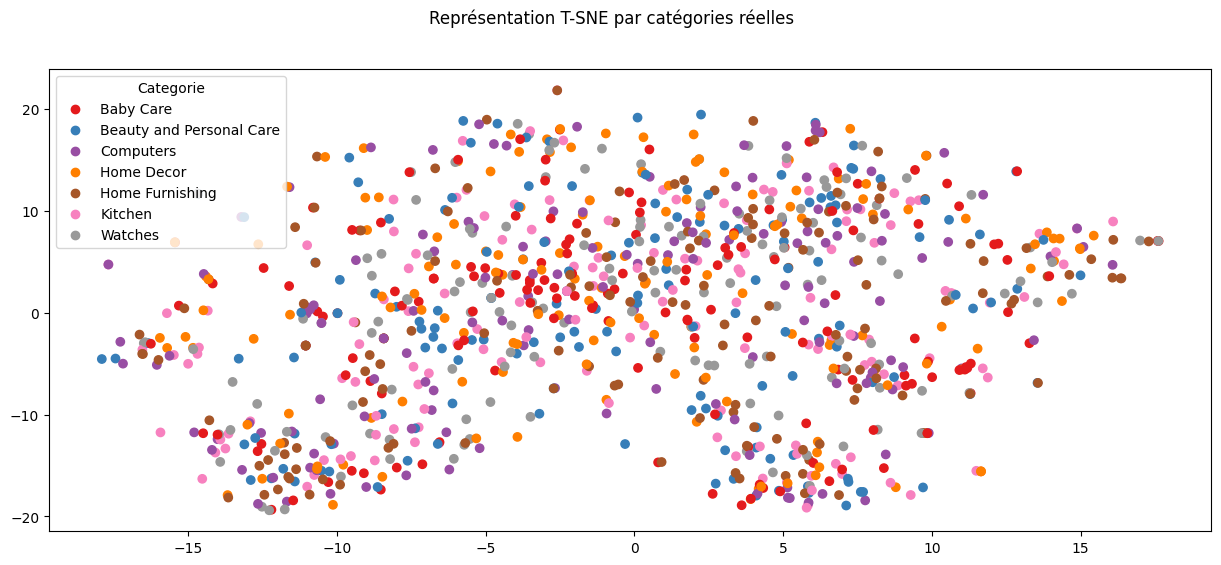

CPU times: user 18.1 s, sys: 28.1 ms, total: 18.2 s
Wall time: 4.44 s


In [37]:
%%time
fig = plt.figure(figsize=(15,6))
colors, _= pd.factorize(data.category)
tsne_data = []
tsne = TSNE(n_components=2, perplexity=70, random_state=42)
s = MinMaxScaler()
scaled_vgg_X_tsne = tsne.fit_transform(s.fit_transform(vgg_features))
vgg_X_tsne = s.fit_transform(vgg_features)
scatter = plt.scatter(scaled_vgg_X_tsne[:,0],scaled_vgg_X_tsne[:,1], c=data.encoded_category.tolist(), cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(data.category).tolist(), loc="best", title="Categorie")

plt.suptitle("Représentation T-SNE par catégories réelles")
plt.show()

### 3.2.2 Kmeans clustering

In [38]:
cls = KMeans(n_clusters=k, n_init=100, random_state=42)
clusters = cls.fit_predict(scaled_vgg_X_tsne)
ARI_1 = np.round(adjusted_rand_score(data.encoded_category, clusters),4)
clusters = cls.fit_predict(vgg_X_tsne)
ARI_2 = np.round(adjusted_rand_score(data.encoded_category, clusters),4)
print("ARI : ", ARI_1)
print("ARI : ", ARI_2)

ARI :  -0.0003
ARI :  0.0


ARI :  -0.0001


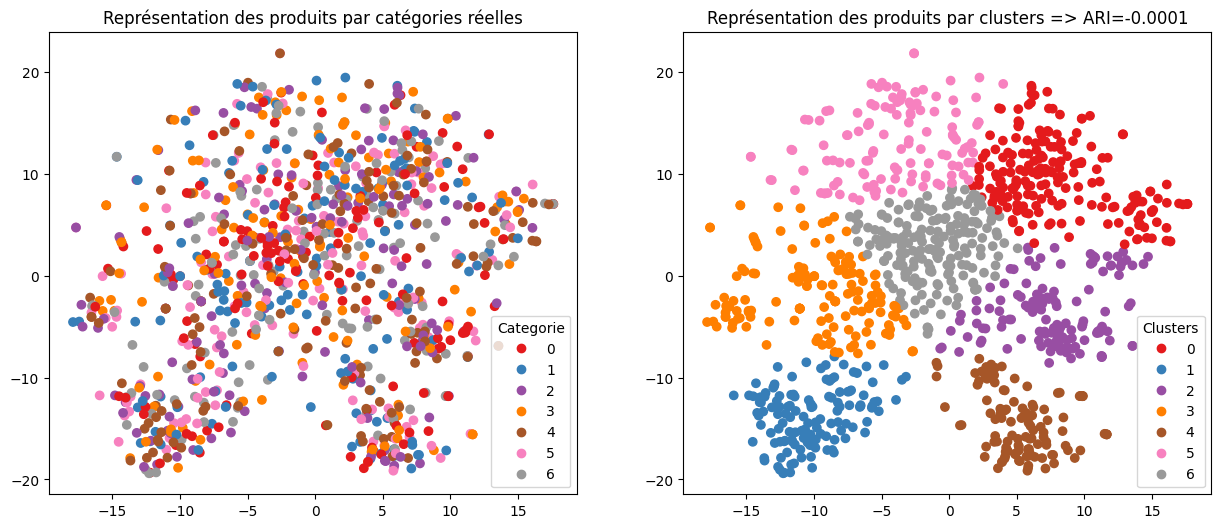

CPU times: user 1.32 s, sys: 11.3 ms, total: 1.34 s
Wall time: 402 ms


In [39]:
%%time

# Détermination des clusters à partir des données reduites
k=7
# Scaler

s_vgg_X_tsne = scaled_vgg_X_tsne
cls = KMeans(n_clusters=k, random_state=42)
clusters = cls.fit_predict(s_vgg_X_tsne)
ARI = np.round(adjusted_rand_score(data.encoded_category, clusters),4)
results["Vgg16"] = {
    'Silhouette score': silhouette_score(s_vgg_X_tsne, clusters, metric='euclidean'),
    'Davies-Bouldin score': davies_bouldin_score(s_vgg_X_tsne, clusters),
}
print("ARI : ", ARI)
tsne_visu_fct(s_vgg_X_tsne, data.encoded_category.tolist(), clusters, ARI)

## 3.3. Comparaison

### 3.3.1 Approche visuelle

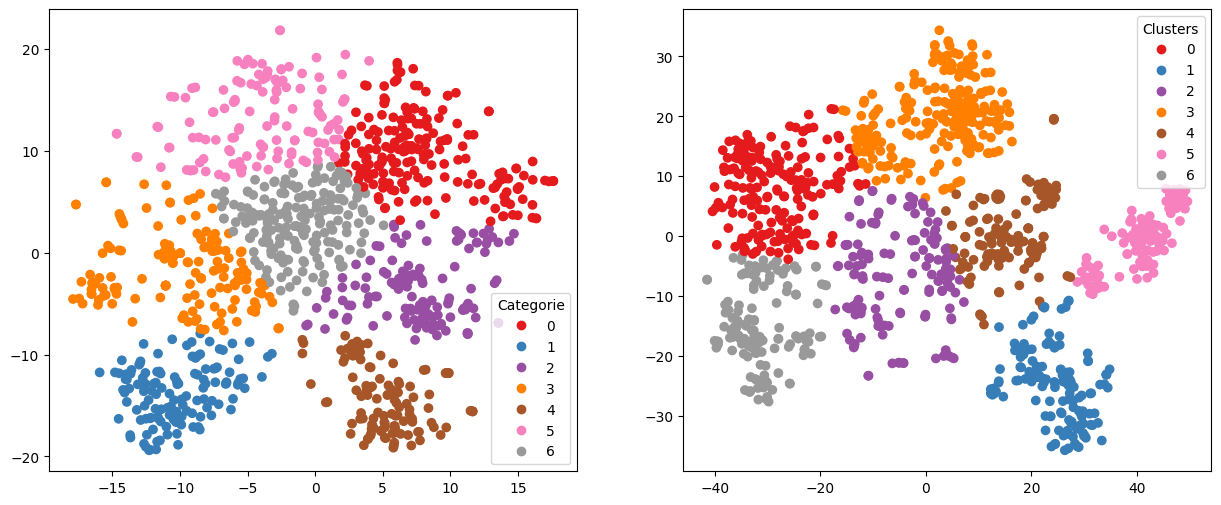

In [40]:
fig = plt.figure(figsize=(15,6))
ax = fig.add_subplot(121)
clusters1 = cls.fit_predict(s_vgg_X_tsne)
clusters2 = cls.fit_predict(resnet50_X_tsne)


scatter = ax.scatter(scaled_vgg_X_tsne[:,0],scaled_vgg_X_tsne[:,1], c=clusters1, cmap='Set1')
ax.legend(handles=scatter.legend_elements()[0], labels=set(clusters1), loc="best", title="Categorie")
#plt.title(f"Représentation des produits par catégories réelles")

ax = fig.add_subplot(122)
scatter = ax.scatter(resnet50_X_tsne[:,0],resnet50_X_tsne[:,1], c=clusters2, cmap='Set1')
ax.legend(handles=scatter.legend_elements()[0], labels=set(clusters2), loc="best", title="Clusters")
#plt.title(f"Représentation des produits par clusters => ARI={ARI}")
plt.show()

### 3.3.2 Approche quantitative

- Une valeur elevée Silhouette score indique des clusters plus compacts et mieux séparés (donc un meilleur clustering).

- Une valeur faible de Davies-Bouldin score indique des clusters plus compacts et mieux séparés (donc un meilleur clustering).

In [41]:
result_df = pd.DataFrame(results).T
result_df

,Silhouette score,Davies-Bouldin score
Resnet50,0.468364,0.689748
Vgg16,0.408013,0.776937


🧠 Conclusion : Les features extraites par ResNet50 semblent offrir une meilleure séparation des classes que celles de VGG16 pour ce dataset. Elles sont donc plus adaptées pour un apprentissage non supervisé ou un clustering efficace dans ce cas précis.

# 4. Classification supervisée

Nous allons utilisées les features extraites à partir de notre modéle precedent de resnet50

In [42]:
train_ds = df_to_dataset(train_df, batch_size=32, shuffle=True, encoded_category=True)
validation_ds = df_to_dataset(val_df, batch_size=32, shuffle=False, encoded_category=True)
test_ds = df_to_dataset(test_df, batch_size=32, shuffle=False, encoded_category=True)

## 4.1 Augmentation du jeu d'entrainement

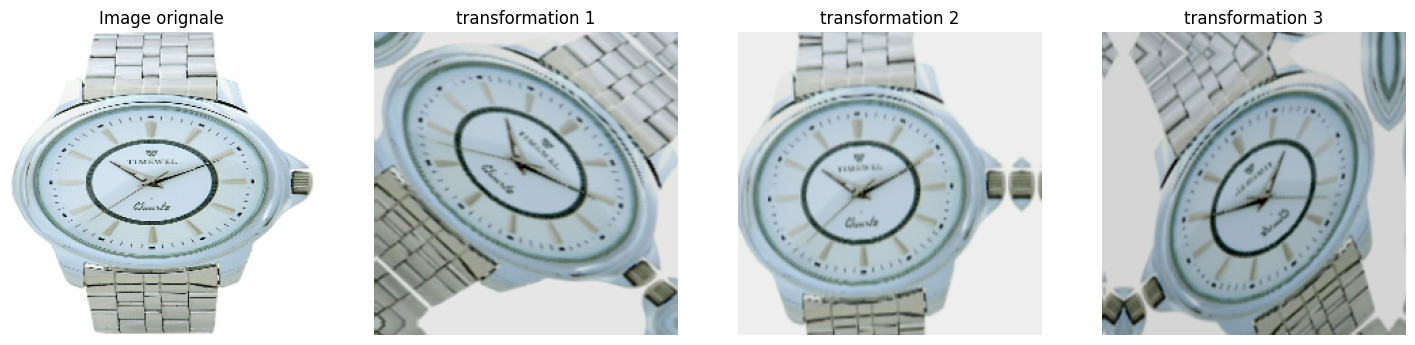

In [43]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),                       # Flip horizontal
    tf.keras.layers.RandomRotation(0.2),                            # Rotation aléatoire
    tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2),  # Zoom aléatoire
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),  # Translation aléatoire
    tf.keras.layers.RandomContrast(0.2),                            # Contraste aléatoire
    tf.keras.layers.RandomBrightness(factor=0.2),                   # Luminosité aléatoire (TF >= 2.15)
])

for image, labels in train_ds.take(1):
  plt.figure(figsize=(18, 8))
  first_image = image[0]
  k = labels[0].numpy()
  ax = plt.subplot(1, 4, 1)
  plt.imshow(first_image / 255)
  plt.title(f"Image orignale")
  plt.axis('off')
  for i in range(3):
    ax = plt.subplot(1, 4, i + 2)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.title(f"transformation {i+1}")
    plt.axis('off')

## 4.2. Modélisation

In [44]:
# Chargement du modèle ResNet50 sans la tête (top) et avec poids ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
# Gel des couches convolutives pour ne pas les réentraîner au début
base_model.trainable = False
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,472 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, None,      │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, None,      │          0 │ conv2_block1_2_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, None,      │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, None,      │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, None,      │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [45]:
%%time
train_features, train_labels = extract_features(train_ds, base_model)
val_features, val_labels = extract_features(validation_ds, base_model)
test_features, test_labels = extract_features(test_ds, base_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [46]:
print("Train features shape:", train_features.shape)
print("Validation features shape:", val_features.shape)
print("Test features shape:", test_features.shape)

Train features shape: (735, 2048)
Validation features shape: (252, 2048)
Test features shape: (63, 2048)


In [47]:
%%time
# Nouvelle tête
inputs = Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = resnet_preprocess_input(x)
x = base_model(inputs, training=False)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(7, activation='softmax')(x)

model = Model(inputs, outputs)

CPU times: user 49.5 ms, sys: 4.75 ms, total: 54.2 ms
Wall time: 48.1 ms


In [48]:
%%time
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.4082 - loss: 1.7783 - val_accuracy: 0.7698 - val_loss: 0.7019
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8047 - loss: 0.6597 - val_accuracy: 0.8095 - val_loss: 0.6328
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9072 - loss: 0.3633 - val_accuracy: 0.7937 - val_loss: 0.6945
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9006 - loss: 0.3073 - val_accuracy: 0.7817 - val_loss: 0.6895
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9380 - loss: 0.1932 - val_accuracy: 0.7897 - val_loss: 0.6852
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9614 - loss: 0.1439 - val_accuracy: 0.8056 - val_loss: 0.6965
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9811 - loss: 0.1080 - val_accuracy: 0.8135 - val_loss: 0.6668
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9801 - loss: 0.0989 - val_accuracy: 0.8095 - val_loss:

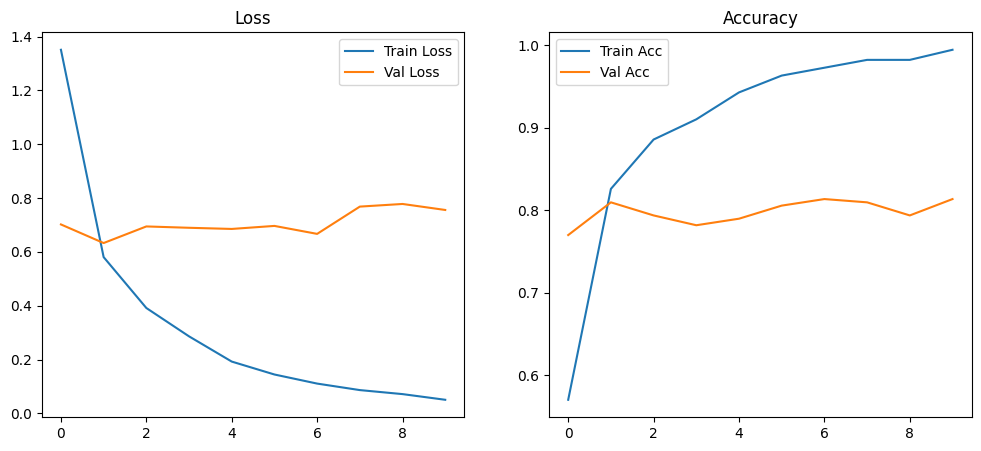

Test dataset evaluation
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8211 - loss: 0.7550


[0.7620687484741211, 0.8253968358039856]

In [49]:
# Courbes Loss/Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()
print("Test dataset evaluation")
model.evaluate(test_ds)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 202s 7s/step - accuracy: 0.9539 - loss: 0.1718 - val_accuracy: 0.5754 - val_loss: 1.5206
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 163s 7s/step - accuracy: 0.9711 - loss: 0.1221 - val_accuracy: 0.6310 - val_loss: 1.3197
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 162s 7s/step - accuracy: 0.9743 - loss: 0.1712 - val_accuracy: 0.6706 - val_loss: 1.2069
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 161s 7s/step - accuracy: 0.9928 - loss: 0.0649 - val_accuracy: 0.6984 - val_loss: 1.1383
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 162s 7s/step - accuracy: 0.9924 - loss: 0.0701 - val_accuracy: 0.7103 - val_loss: 1.0889
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 161s 7s/step - accuracy: 0.9836 - loss: 0.0491 - val_accuracy: 0.7262 - val_loss: 1.0671
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 161s 7s/step - accuracy: 0.9980 - loss: 0.0277 - val_accuracy: 0.7381 - val_loss: 1.0544
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 161s 7s/step - accuracy: 0.9963 - loss: 0.0307 - val_accuracy: 0.7341 - v

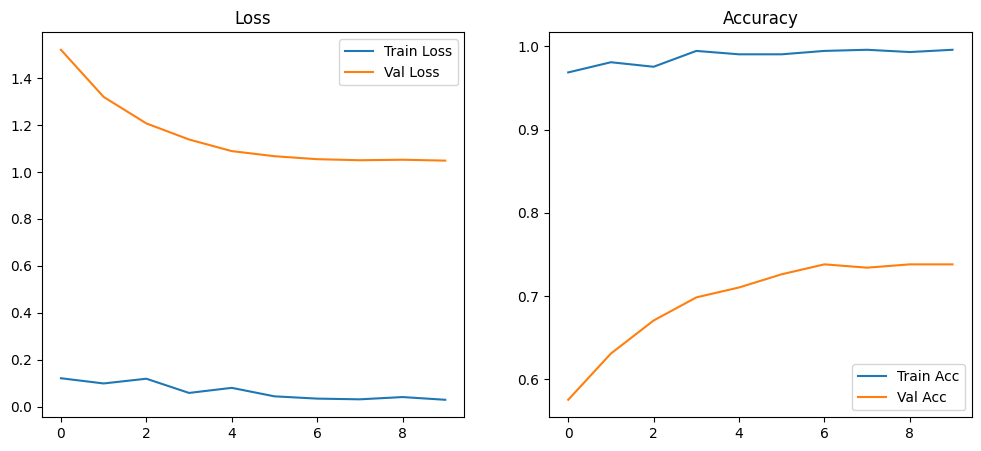

CPU times: user 2h 41min 1s, sys: 17min 6s, total: 2h 58min 7s
Wall time: 26min 54s


In [55]:
%%time
# Unfreeze the base model
base_model.trainable = True

model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
]

# Train end-to-end. Be careful to stop before you overfit!
h = model.fit(train_ds, epochs=10, validation_data=validation_ds, callbacks=callbacks)
# Courbes Loss/Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(h.history['loss'], label='Train Loss')
plt.plot(h.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h.history['accuracy'], label='Train Acc')
plt.plot(h.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

In [54]:
print("Test dataset evaluation")
model.evaluate(test_ds)

Test dataset evaluation
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4211 - loss: 2.0105


[2.0148117542266846, 0.4285714328289032]

In [57]:
predictions = model.predict(test_ds)
pred_labels = np.argmax(predictions, axis=1)
class_names = test_ds.class_names

# Ground truth
true_labels = np.concatenate([y.numpy() for x, y in test_ds])
images = np.concatenate([x.numpy() for x, y in test_ds])

# Affichage des erreurs
import random
wrong_indices = np.where(pred_labels != true_labels)[0]
for idx in random.sample(list(wrong_indices), 5):
    plt.imshow(images[idx].astype("uint8"))
    plt.title(f"Vrai: {class_names[true_labels[idx]]} | Prédit: {class_names[pred_labels[idx]]}")
    plt.axis("off")
    plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 988ms/step


AttributeError: '_PrefetchDataset' object has no attribute 'class_names'